In [ ]:
#Data Preprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/preprocessing_dataset.csv')
df1=df.copy()
df2=df.copy()
df3=df.copy()

In [ ]:
df.head()

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT


In [ ]:
df.tail()

,Name,Age,Gender,Salary,Department
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        10 non-null     object 
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   Salary      9 non-null      float64
 4   Department  10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


In [ ]:
df.isnull().sum()

,0
Name,0
Age,1
Gender,1
Salary,1
Department,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        10 non-null     object 
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   Salary      9 non-null      float64
 4   Department  10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


In [ ]:
df.describe()

,Age,Salary
count,9.000000,9.000000
mean,39.555556,57777.777778
std,30.631320,4521.553322
min,22.000000,50000.000000
25%,27.000000,55000.000000
50%,29.000000,59000.000000
75%,35.000000,61000.000000
max,120.000000,63000.000000


In [ ]:
df.shape

(10, 5)

In [ ]:
df

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [ ]:
df.isnull().sum()

,0
Name,0
Age,1
Gender,1
Salary,1
Department,0


In [ ]:
!pip install missingno
import missingno as msno


<Axes: >

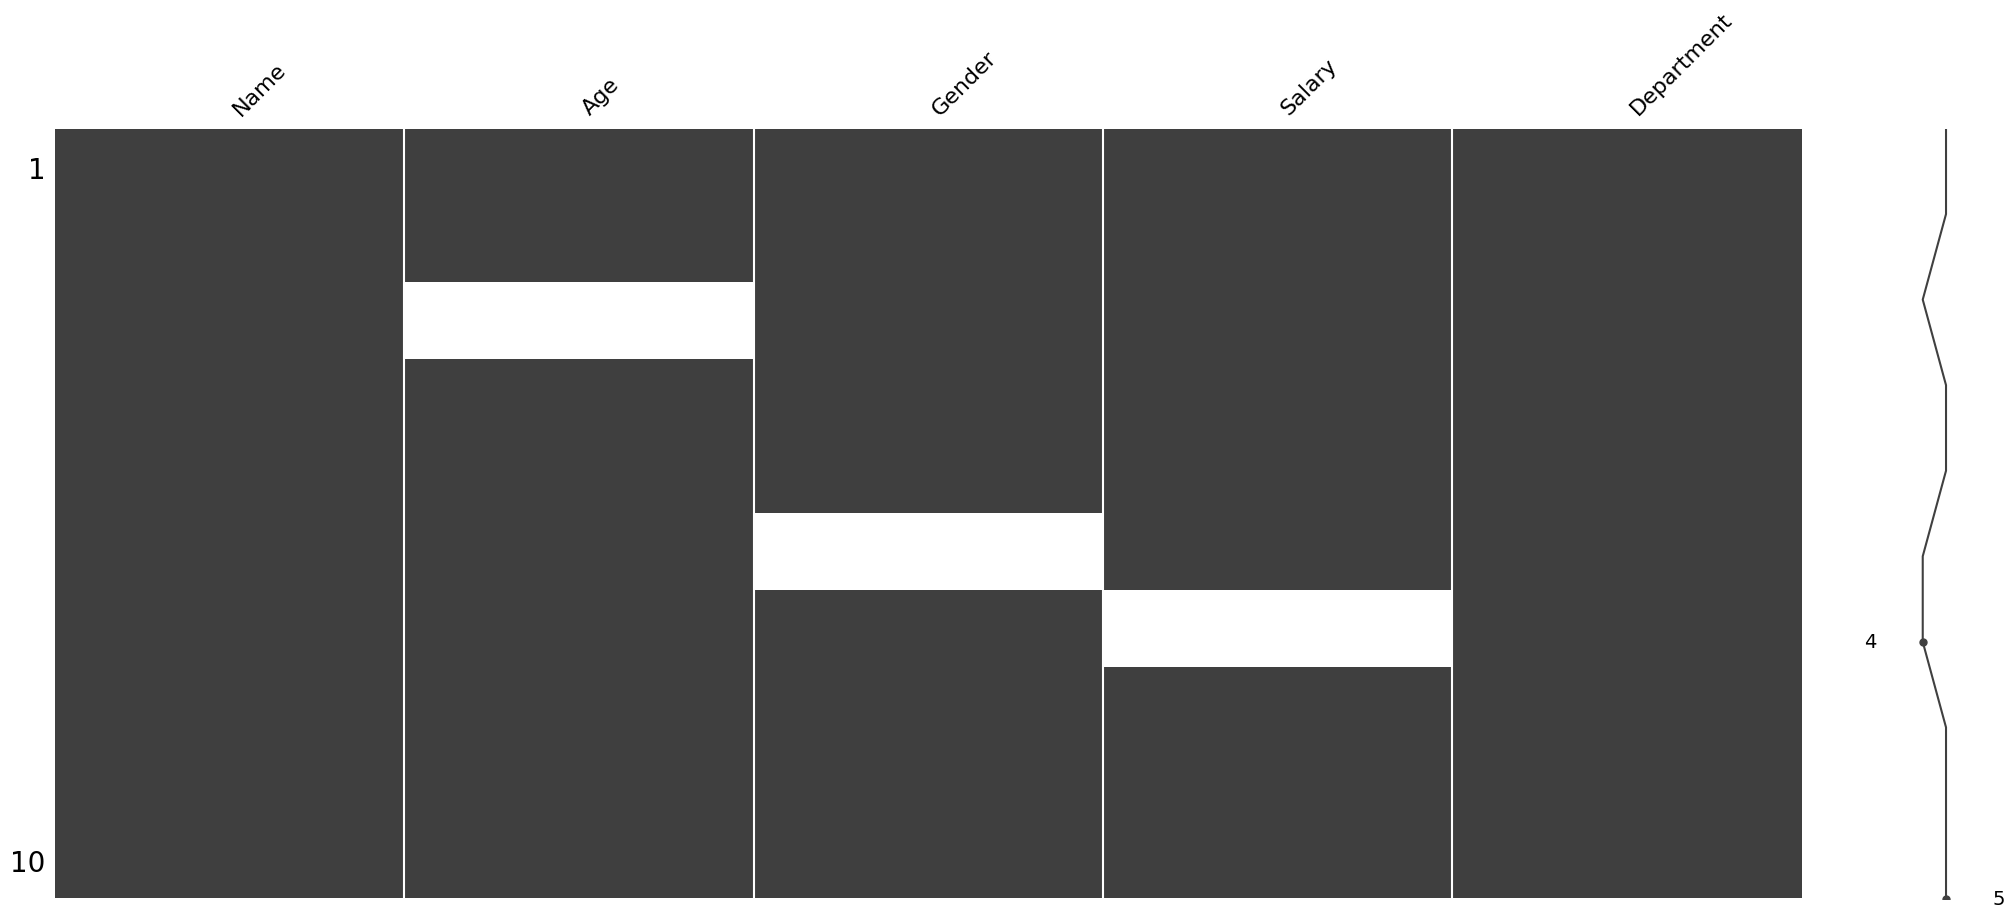

In [ ]:
msno.matrix(df)

<Axes: >

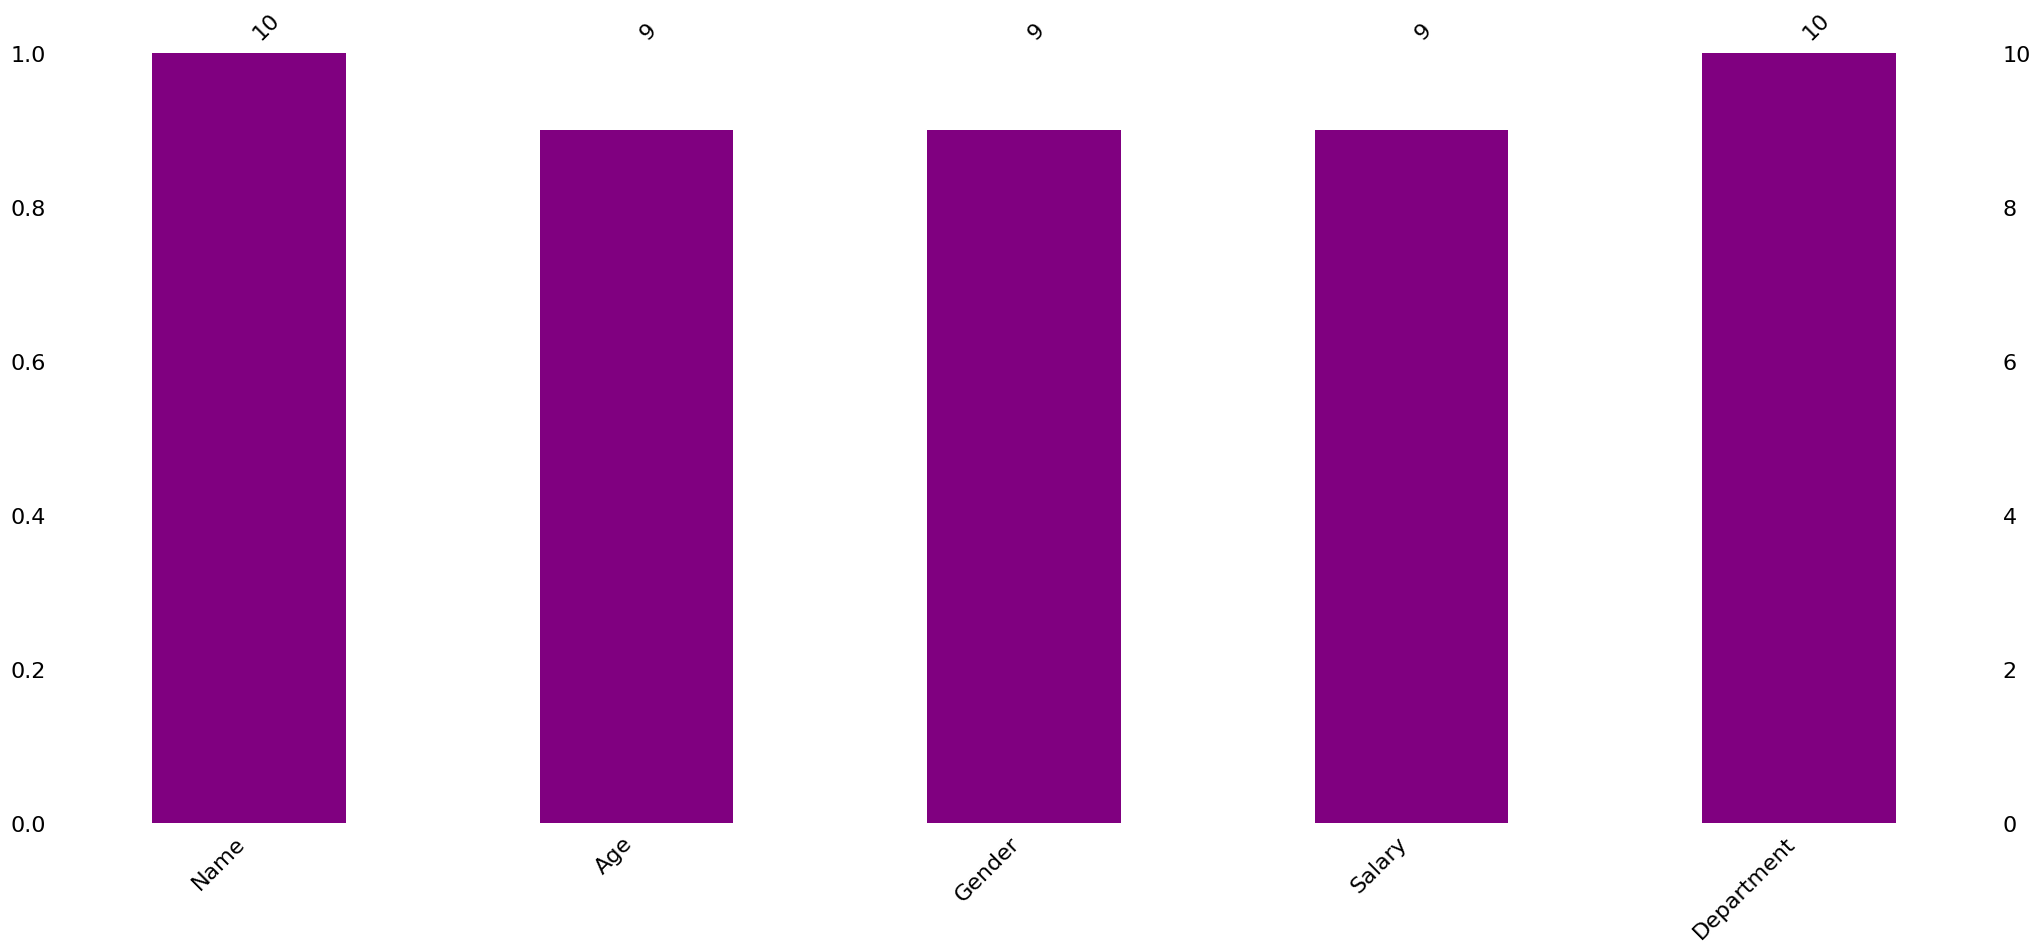

In [ ]:
msno.bar(df,color='purple')

<Axes: >

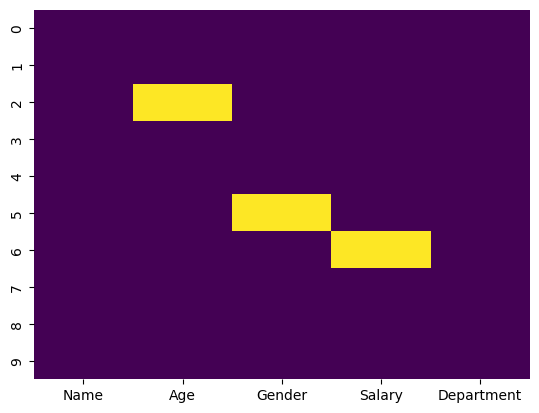

In [ ]:
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')

In [ ]:
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Salary']=df['Salary'].fillna(df['Salary'].mean())
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
#Or we use inplace=True df['Age'].fillna(df['Age'].mean(),inplace=True)

In [ ]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Salary,0
Department,0


In [ ]:
from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy='mean')
df1[['Age']]=imp.fit_transform(df1[['Age']])

In [ ]:

df1[['Salary']]=imp.fit_transform(df1[['Salary']])

In [ ]:
from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy='most_frequent')
df1[['Gender']]=imp.fit_transform(df1[['Gender']])

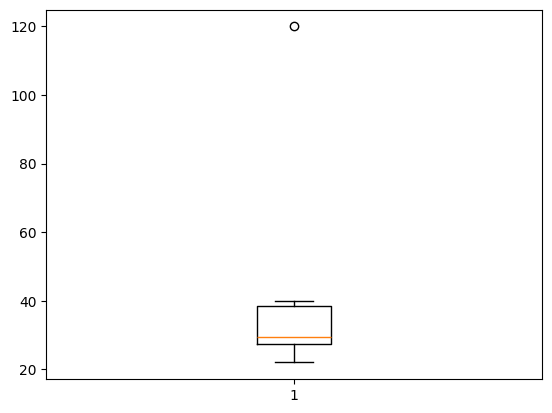

In [ ]:
plt.boxplot(df1['Age'])
plt.show()

In [ ]:
Q1=df1['Age'].quantile(0.25)
Q3=df1['Age'].quantile(0.75)
IQR=Q3-Q1

In [ ]:
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

In [ ]:
outlier=df1[(df1['Age']<lower) | (df1['Age']>upper)]

In [ ]:
outlier

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,57777.777778,Finance


In [ ]:
from scipy.stats import zscore

In [ ]:
zscore=zscore(df['Age'])
print(zscore)

[-0.53127341 -0.34877491  0.          0.01622209 -0.64077251 -0.16627641
  2.93619806 -0.42177431 -0.38527461 -0.45827401]


In [ ]:
df[np.abs(zscore)>2.9]

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,NaN,Finance


In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
iso=IsolationForest(contamination=0.4)
df['outlier']=iso.fit_predict(df1[['Age','Salary']])

In [ ]:
df

,Name,Age,Gender,Salary,Department,outlier
0,Alice,25.000000,F,50000.0,HR,1
1,Bob,30.000000,M,60000.0,Finance,1
2,Charlie,39.555556,M,55000.0,IT,1
3,David,40.000000,M,58000.0,HR,1
4,Eve,22.000000,F,52000.0,IT,1
5,Frank,35.000000,NaN,61000.0,Finance,1
6,Grace,120.000000,F,NaN,Finance,-1
7,Henry,28.000000,M,59000.0,HR,1
8,Ivy,29.000000,F,63000.0,IT,1
9,Jack,27.000000,M,62000.0,Finance,1
